# 🚨 Por Qué Proyectar Solo Con Ventas Es Un Error Costoso

## El Problema Invisible: Backorders

Cuando una empresa tiene problemas de inventario (backorders), **las ventas registradas NO representan la demanda real del mercado**.

Este análisis demuestra:
1. **Cuánta demanda real está siendo ignorada (en cantidad y dinero)**
2. **El impacto financiero de proyecciones incorrectas**
3. **Por qué necesitan un modelo predictivo que considere backorders**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configuración de pandas para mejor visualización
pd.options.display.float_format = '{:,.2f}'.format


## 1️⃣ Cargando los Datos


In [2]:
# Cargar datos
sales = pd.read_csv('sales.csv')
backorder = pd.read_csv('backorder.csv')

# Convertir fechas
sales['date'] = pd.to_datetime(sales['date'])
backorder['date'] = pd.to_datetime(backorder['date'])

print("📋 Estructura de sales.csv:", sales.columns.tolist())
print("📋 Estructura de backorder.csv:", backorder.columns.tolist())

# Combinar datasets
df = pd.merge(sales, backorder, on='date', how='outer')
df = df.sort_values('date').fillna(0)

# Calcular la DEMANDA REAL (lo que los clientes realmente querían comprar)
df['real_demand_quantity'] = df['sales_quantity'] + df['backorder_quantity']
df['real_demand_money'] = df['net_sales'] + df['backorder_money']

print(f"\n📊 Período de análisis: {df['date'].min().strftime('%Y-%m-%d')} a {df['date'].max().strftime('%Y-%m-%d')}")
print(f"📅 Total de días: {len(df)}")
print("\n✅ Datos cargados exitosamente")
print("\n🔍 Vista previa:")
df.head()


📋 Estructura de sales.csv: ['date', 'sales_quantity', 'net_sales']
📋 Estructura de backorder.csv: ['date', 'backorder_quantity', 'backorder_money']

📊 Período de análisis: 2024-01-02 a 2025-11-22
📅 Total de días: 593

✅ Datos cargados exitosamente

🔍 Vista previa:


,date,sales_quantity,net_sales,backorder_quantity,backorder_money,real_demand_quantity,real_demand_money
0,2024-01-02,"18,275.18","221,526.40","2,693.50","43,239.34","20,968.68","264,765.74"
1,2024-01-03,"10,446.52","116,917.35","1,340.27","19,009.70","11,786.79","135,927.05"
2,2024-01-04,"18,789.52","213,951.04","4,283.94","58,908.59","23,073.46","272,859.63"
3,2024-01-05,"13,780.67","178,494.91","2,447.91","40,849.11","16,228.58","219,344.02"
4,2024-01-06,"13,762.91","168,587.46","2,710.24","53,612.34","16,473.15","222,199.80"


## 2️⃣ La Verdad Oculta: Ventas vs Demanda Real

### ¿Qué pasa cuando proyectas solo con ventas pero tienes backorders?


In [3]:
# Estadísticas clave en CANTIDAD
total_sales_qty = df['sales_quantity'].sum()
total_backorders_qty = df['backorder_quantity'].sum()
total_real_demand_qty = df['real_demand_quantity'].sum()

# Estadísticas clave en DINERO
total_sales_money = df['net_sales'].sum()
total_backorders_money = df['backorder_money'].sum()
total_real_demand_money = df['real_demand_money'].sum()

# El error de ignorar backorders
demand_missed_pct_qty = (total_backorders_qty / total_real_demand_qty) * 100
demand_missed_pct_money = (total_backorders_money / total_real_demand_money) * 100

print("=" * 80)
print("💰 EL COSTO DE IGNORAR BACKORDERS")
print("=" * 80)
print("\n📦 EN CANTIDAD (Unidades):")
print(f"   Ventas registradas:                {total_sales_qty:,.2f}")
print(f"   Backorders (demanda no satisfecha): {total_backorders_qty:,.2f}")
print(f"   DEMANDA REAL:                      {total_real_demand_qty:,.2f}")
print(f"   ⚠️  Estás ignorando el {demand_missed_pct_qty:.1f}% de la demanda real")

print("\n💵 EN DINERO (Ingresos):")
print(f"   Ventas registradas:                ${total_sales_money:,.2f}")
print(f"   Backorders (ingresos perdidos):    ${total_backorders_money:,.2f}")
print(f"   POTENCIAL REAL:                    ${total_real_demand_money:,.2f}")
print(f"   ⚠️  Estás perdiendo el {demand_missed_pct_money:.1f}% de ingresos potenciales")

print("\n" + "=" * 80)
print("💸 OPORTUNIDAD PERDIDA EN EL PERÍODO")
print("=" * 80)
print(f"   Unidades no vendidas:  {total_backorders_qty:,.2f}")
print(f"   Ingresos no capturados: ${total_backorders_money:,.2f}")
print("\n🔴 Si proyectas solo con ventas históricas, seguirás subestimando")
print(f"   la demanda en aproximadamente {demand_missed_pct_money:.1f}% cada mes.")
print("=" * 80)


💰 EL COSTO DE IGNORAR BACKORDERS

📦 EN CANTIDAD (Unidades):
   Ventas registradas:                9,740,598.41
   Backorders (demanda no satisfecha): 1,860,379.72
   DEMANDA REAL:                      11,600,978.13
   ⚠️  Estás ignorando el 16.0% de la demanda real

💵 EN DINERO (Ingresos):
   Ventas registradas:                $109,358,166.90
   Backorders (ingresos perdidos):    $20,583,972.74
   POTENCIAL REAL:                    $129,942,139.64
   ⚠️  Estás perdiendo el 15.8% de ingresos potenciales

💸 OPORTUNIDAD PERDIDA EN EL PERÍODO
   Unidades no vendidas:  1,860,379.72
   Ingresos no capturados: $20,583,972.74

🔴 Si proyectas solo con ventas históricas, seguirás subestimando
   la demanda en aproximadamente 15.8% cada mes.


## 3️⃣ Visualización del Problema


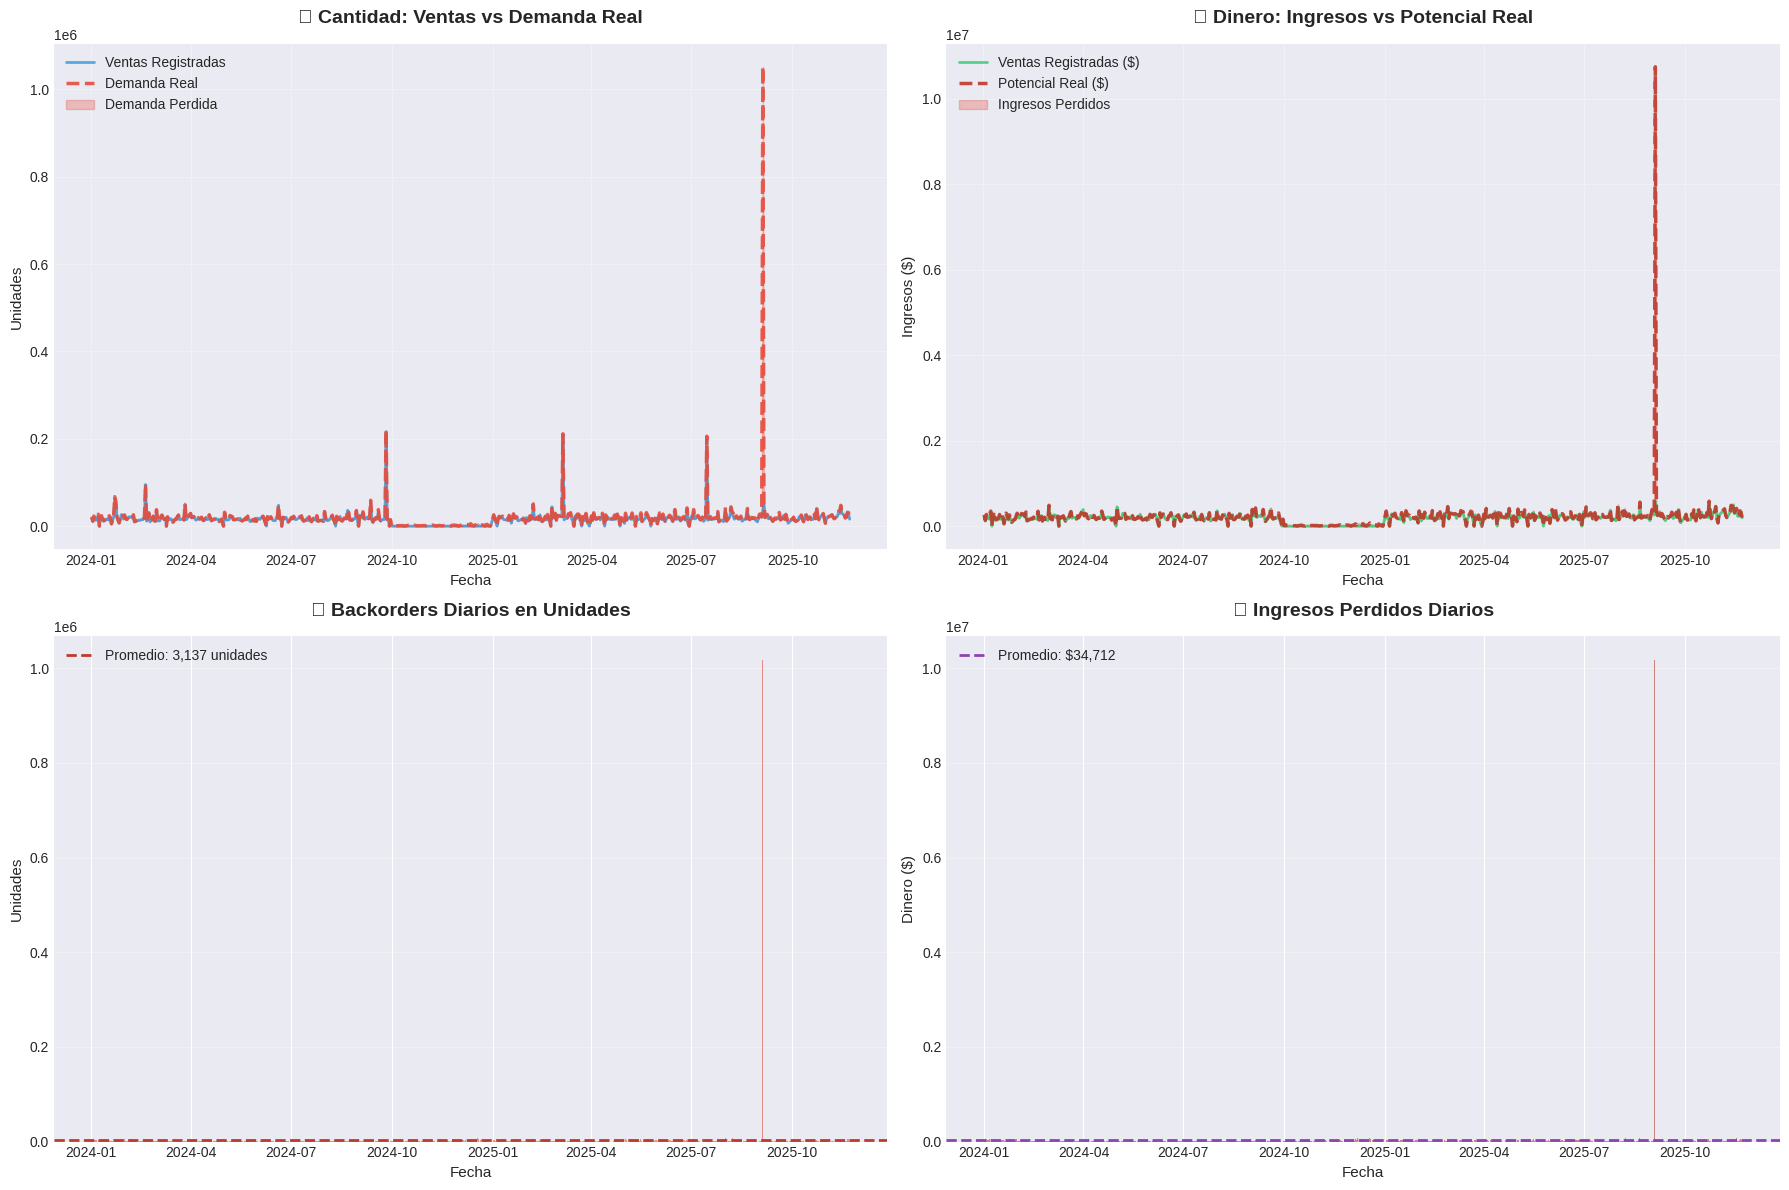

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Panel 1A: Series de tiempo - CANTIDAD
ax1 = axes[0, 0]
ax1.plot(df['date'], df['sales_quantity'], label='Ventas Registradas', linewidth=2, color='#3498db', alpha=0.8)
ax1.plot(df['date'], df['real_demand_quantity'], label='Demanda Real', linewidth=2.5, color='#e74c3c', linestyle='--', alpha=0.9)
ax1.fill_between(df['date'], df['sales_quantity'], df['real_demand_quantity'], alpha=0.3, color='#e74c3c', label='Demanda Perdida')
ax1.set_title('🚨 Cantidad: Ventas vs Demanda Real', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Unidades', fontsize=11)
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3)

# Panel 1B: Series de tiempo - DINERO
ax2 = axes[0, 1]
ax2.plot(df['date'], df['net_sales'], label='Ventas Registradas ($)', linewidth=2, color='#2ecc71', alpha=0.8)
ax2.plot(df['date'], df['real_demand_money'], label='Potencial Real ($)', linewidth=2.5, color='#c0392b', linestyle='--', alpha=0.9)
ax2.fill_between(df['date'], df['net_sales'], df['real_demand_money'], alpha=0.3, color='#e74c3c', label='Ingresos Perdidos')
ax2.set_title('💰 Dinero: Ingresos vs Potencial Real', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Ingresos ($)', fontsize=11)
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3)

# Panel 2A: Backorders CANTIDAD
ax3 = axes[1, 0]
ax3.bar(df['date'], df['backorder_quantity'], color='#e74c3c', alpha=0.6, width=1)
ax3.axhline(y=df['backorder_quantity'].mean(), color='#c0392b', linestyle='--', linewidth=2, label=f'Promedio: {df["backorder_quantity"].mean():,.0f} unidades')
ax3.set_title('📊 Backorders Diarios en Unidades', fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Fecha', fontsize=11)
ax3.set_ylabel('Unidades', fontsize=11)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# Panel 2B: Backorders DINERO
ax4 = axes[1, 1]
ax4.bar(df['date'], df['backorder_money'], color='#c0392b', alpha=0.6, width=1)
ax4.axhline(y=df['backorder_money'].mean(), color='#8e44ad', linestyle='--', linewidth=2, label=f'Promedio: ${df["backorder_money"].mean():,.0f}')
ax4.set_title('💸 Ingresos Perdidos Diarios', fontsize=14, fontweight='bold', pad=15)
ax4.set_xlabel('Fecha', fontsize=11)
ax4.set_ylabel('Dinero ($)', fontsize=11)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 4️⃣ El Impacto Mensual


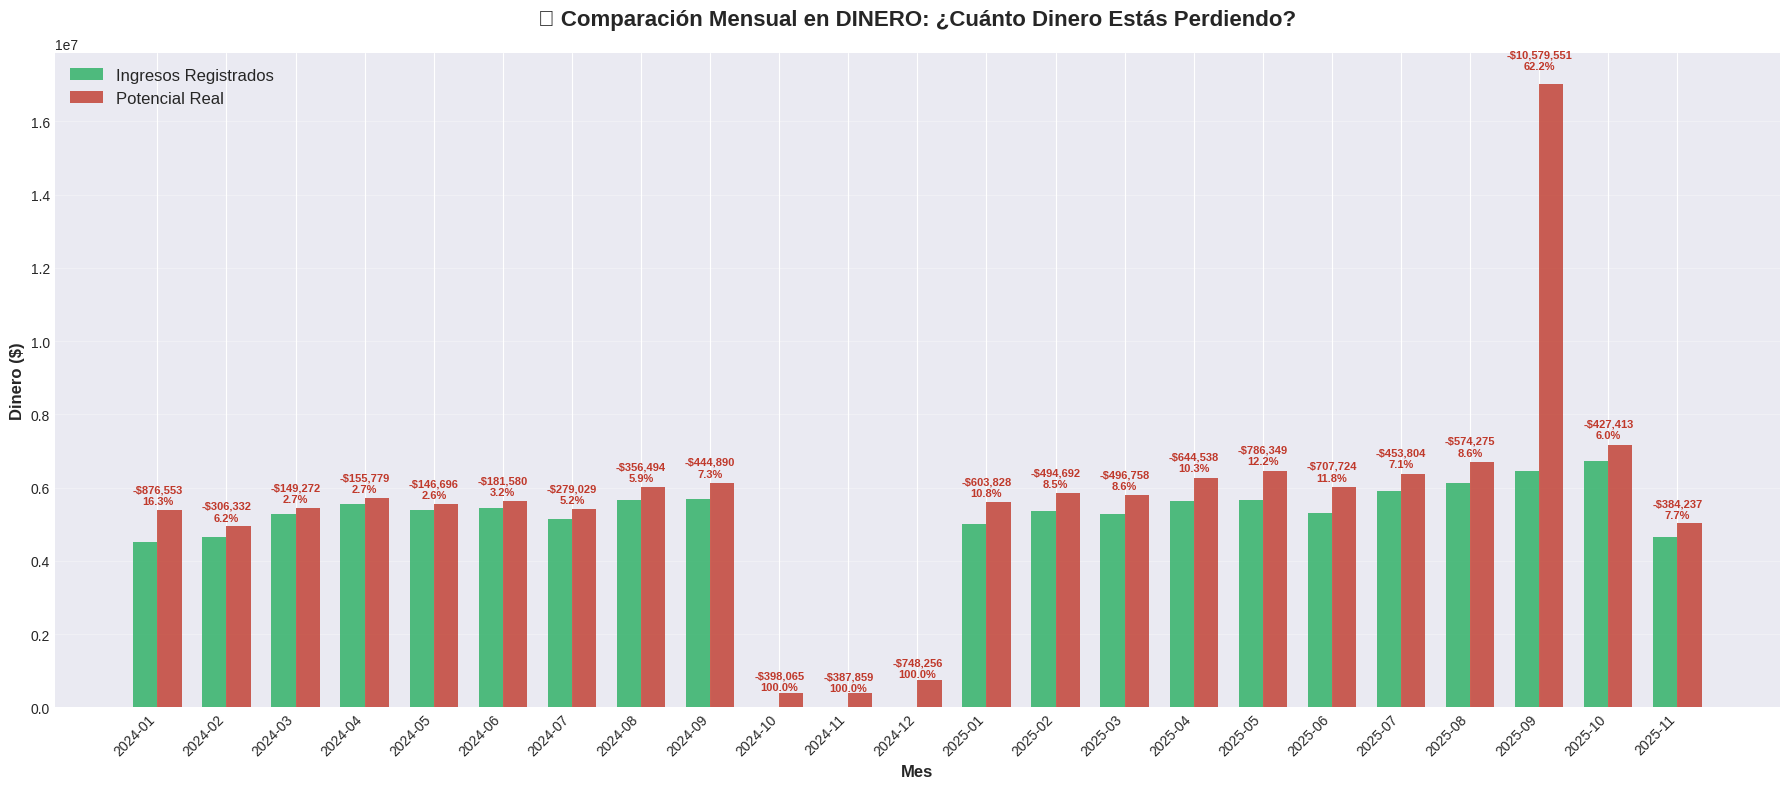


📊 Promedio mensual de ingresos perdidos: $894,955.34


In [5]:
# Análisis mensual
df['year_month'] = df['date'].dt.to_period('M')

monthly = df.groupby('year_month').agg({
    'sales_quantity': 'sum',
    'net_sales': 'sum',
    'backorder_quantity': 'sum',
    'backorder_money': 'sum',
    'real_demand_quantity': 'sum',
    'real_demand_money': 'sum'
}).reset_index()

monthly['error_pct_qty'] = (monthly['backorder_quantity'] / monthly['real_demand_quantity'] * 100)
monthly['error_pct_money'] = (monthly['backorder_money'] / monthly['real_demand_money'] * 100)
monthly['year_month'] = monthly['year_month'].astype(str)

# Visualización mensual - Dinero
fig, ax = plt.subplots(figsize=(18, 8))
x = np.arange(len(monthly))
width = 0.35

bars1 = ax.bar(x - width/2, monthly['net_sales'], width, label='Ingresos Registrados', color='#27ae60', alpha=0.8)
bars2 = ax.bar(x + width/2, monthly['real_demand_money'], width, label='Potencial Real', color='#c0392b', alpha=0.8)

ax.set_xlabel('Mes', fontsize=12, fontweight='bold')
ax.set_ylabel('Dinero ($)', fontsize=12, fontweight='bold')
ax.set_title('💰 Comparación Mensual en DINERO: ¿Cuánto Dinero Estás Perdiendo?', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(monthly['year_month'], rotation=45, ha='right')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Etiquetas de dinero perdido
for i, (idx, row) in enumerate(monthly.iterrows()):
    loss = row['backorder_money']
    ax.text(i, row['real_demand_money'] + row['real_demand_money']*0.02, f"-${loss:,.0f}\n{row['error_pct_money']:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold', color='#c0392b')

plt.tight_layout()
plt.show()

print("\n📊 Promedio mensual de ingresos perdidos: ${:,.2f}".format(monthly['backorder_money'].mean()))


## 5️⃣ Simulación: Proyección a 6 Meses


In [6]:
# Simulación de proyecciones
avg_monthly_sales_money = monthly['net_sales'].mean()
avg_monthly_real_demand_money = monthly['real_demand_money'].mean()
avg_error_pct = monthly['error_pct_money'].mean()
months_projection = 6

print("=" * 90)
print("🔮 SIMULACIÓN: PRÓXIMOS 6 MESES")
print("=" * 90)
print("\n📌 ESCENARIO A: Si proyectas con VENTAS históricas (método actual)")
print(f"   → Ingresos/mes:         ${avg_monthly_sales_money:,.2f}")
print(f"   → Seguirás perdiendo:   ~{avg_error_pct:.1f}% de demanda cada mes")
print(f"   💸 PÉRDIDA en 6 meses:  ${(avg_monthly_real_demand_money - avg_monthly_sales_money) * months_projection:,.2f}")

print("\n📌 ESCENARIO B: Si proyectas con DEMANDA REAL (solución propuesta)")
print(f"   → Ingresos/mes:         ${avg_monthly_real_demand_money:,.2f}")
print(f"   → Captura de demanda completa del mercado")
print(f"   💰 GANANCIA en 6 meses: ${(avg_monthly_real_demand_money - avg_monthly_sales_money) * months_projection:,.2f}")

total_diff = (avg_monthly_real_demand_money - avg_monthly_sales_money) * months_projection
print(f"\n✨ IMPACTO TOTAL: ${total_diff:,.2f} en 6 meses")
print(f"   (${total_diff/6:,.2f} por mes)")
print("=" * 90)


🔮 SIMULACIÓN: PRÓXIMOS 6 MESES

📌 ESCENARIO A: Si proyectas con VENTAS históricas (método actual)
   → Ingresos/mes:         $4,754,702.91
   → Seguirás perdiendo:   ~22.0% de demanda cada mes
   💸 PÉRDIDA en 6 meses:  $5,369,732.02

📌 ESCENARIO B: Si proyectas con DEMANDA REAL (solución propuesta)
   → Ingresos/mes:         $5,649,658.25
   → Captura de demanda completa del mercado
   💰 GANANCIA en 6 meses: $5,369,732.02

✨ IMPACTO TOTAL: $5,369,732.02 en 6 meses
   ($894,955.34 por mes)


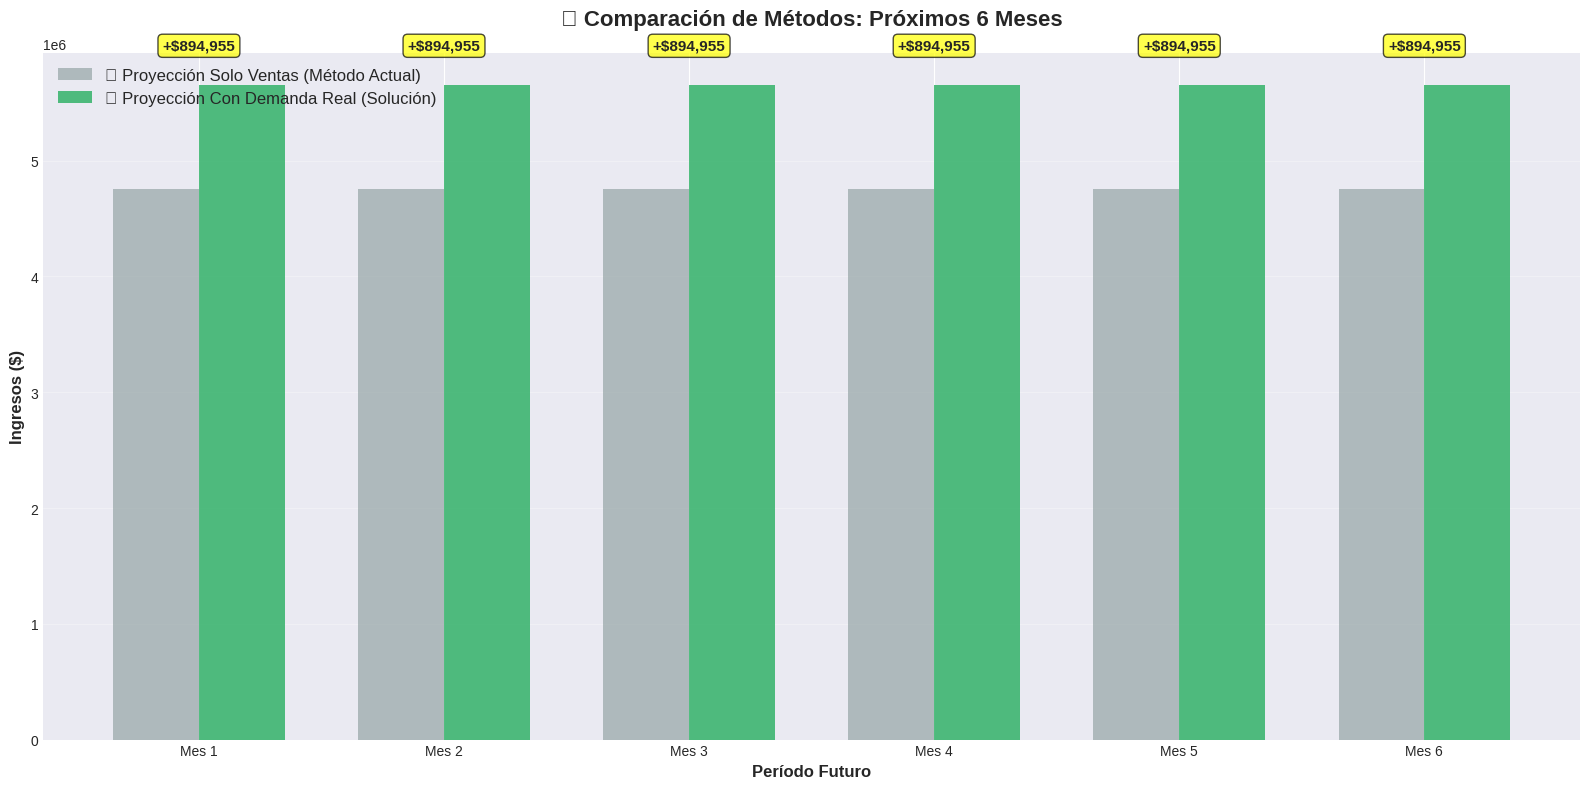

In [7]:
# Visualización de proyección
months_ahead = 6
projection_months = [f'Mes {i+1}' for i in range(months_ahead)]

fig, ax = plt.subplots(figsize=(16, 8))
x = np.arange(months_ahead)
width = 0.35

bars1 = ax.bar(x - width/2, [avg_monthly_sales_money]*months_ahead, width, label='❌ Proyección Solo Ventas (Método Actual)', color='#95a5a6', alpha=0.7)
bars2 = ax.bar(x + width/2, [avg_monthly_real_demand_money]*months_ahead, width, label='✅ Proyección Con Demanda Real (Solución)', color='#27ae60', alpha=0.8)

for i in range(months_ahead):
    diff = avg_monthly_real_demand_money - avg_monthly_sales_money
    ax.text(i, avg_monthly_real_demand_money * 1.05, f'+${diff:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax.set_xlabel('Período Futuro', fontsize=12, fontweight='bold')
ax.set_ylabel('Ingresos ($)', fontsize=12, fontweight='bold')
ax.set_title('🔮 Comparación de Métodos: Próximos 6 Meses', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(projection_months)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 6️⃣ Análisis de Fill Rate y Precio


In [8]:
# Análisis de precio promedio
df['avg_price_sales'] = df['net_sales'] / df['sales_quantity'].replace(0, np.nan)
df['avg_price_backorder'] = df['backorder_money'] / df['backorder_quantity'].replace(0, np.nan)

avg_price_sales = df['avg_price_sales'].mean()
avg_price_backorder = df['avg_price_backorder'].mean()

# Fill Rate
fill_rate_qty = (total_sales_qty / total_real_demand_qty) * 100
fill_rate_money = (total_sales_money / total_real_demand_money) * 100

print("=" * 80)
print("💡 ANÁLISIS DE PRECIO Y FILL RATE")
print("=" * 80)
print(f"\n📊 Precio promedio de productos vendidos:       ${avg_price_sales:.2f}")
print(f"📊 Precio promedio de productos en backorder:   ${avg_price_backorder:.2f}")

if avg_price_backorder > avg_price_sales * 1.1:
    print(f"\n⚠️  ALERTA: Los productos en backorder tienen un precio {((avg_price_backorder/avg_price_sales)-1)*100:.1f}% MAYOR")
    print("   → Estás perdiendo las ventas de productos de mayor valor")
elif avg_price_backorder < avg_price_sales * 0.9:
    print(f"\n💡 Los productos en backorder son de menor precio promedio")
else:
    print(f"\n✓ Los precios promedios son similares")

print(f"\n📊 Fill Rate (Tasa de Cumplimiento):")
print(f"   • En Cantidad:  {fill_rate_qty:.1f}%")
print(f"   • En Dinero:    {fill_rate_money:.1f}%")
print(f"\n💡 Solo estás capturando {fill_rate_money:.1f}% del potencial de mercado")
print("=" * 80)


💡 ANÁLISIS DE PRECIO Y FILL RATE

📊 Precio promedio de productos vendidos:       $12.21
📊 Precio promedio de productos en backorder:   $13.56

⚠️  ALERTA: Los productos en backorder tienen un precio 11.0% MAYOR
   → Estás perdiendo las ventas de productos de mayor valor

📊 Fill Rate (Tasa de Cumplimiento):
   • En Cantidad:  84.0%
   • En Dinero:    84.2%

💡 Solo estás capturando 84.2% del potencial de mercado


## 🎯 CONCLUSIONES Y RESUMEN EJECUTIVO


In [9]:
# Resumen ejecutivo
print("\n" + "="*90)
print("📄 RESUMEN EJECUTIVO")
print("="*90)
print(f"\n🔴 SITUACIÓN ACTUAL:")
print(f"   • Fill Rate: {fill_rate_money:.1f}%")
print(f"   • Ingresos perdidos totales: ${total_backorders_money:,.2f}")
print(f"   • % de demanda ignorada: {demand_missed_pct_money:.1f}%")

print(f"\n💡 OPORTUNIDAD:")
print(f"   • Adicional mensual: ${avg_monthly_real_demand_money - avg_monthly_sales_money:,.2f}")
print(f"   • Proyección 6 meses: ${(avg_monthly_real_demand_money - avg_monthly_sales_money) * 6:,.2f}")
print(f"   • Proyección 12 meses: ${(avg_monthly_real_demand_money - avg_monthly_sales_money) * 12:,.2f}")

print(f"\n✅ SOLUCIÓN:")
print(f"   Modelo predictivo que considera backorders para proyectar demanda REAL")
print(f"   → Mejora precisión de proyecciones")
print(f"   → Optimiza inventario")
print(f"   → Captura demanda completa")
print(f"   → ROI positivo desde mes 1")

print("\n" + "="*90)
print("❌ POR QUÉ EL ENFOQUE ACTUAL NO FUNCIONA:")
print("="*90)
print(f"\n1. Ignoras {demand_missed_pct_money:.1f}% de la demanda real")
print(f"   → ${total_backorders_money:,.2f} en ingresos perdidos")
print("\n2. Ciclo vicioso: Proyectar bajo → Ordenar poco → Más backorders")
print(f"\n3. Pérdida mensual continua de ~${avg_monthly_real_demand_money - avg_monthly_sales_money:,.2f}")

print("\n" + "="*90)
print("✅ POR QUÉ NECESITAN UN MODELO PREDICTIVO:")
print("="*90)
print("\n1. Proyecciones basadas en demanda real (Ventas + Backorders)")
print("\n2. Identifica patrones y tendencias críticas")
print("\n3. ROI inmediato: Captura demanda perdida desde mes 1")
print("\n4. Toma de decisiones data-driven con alertas proactivas")

print("\n" + "="*90)
print("🚀 ¿LISTO PARA CAPTURAR TODA LA DEMANDA Y DEJAR DE PERDER DINERO?")
print("="*90)



📄 RESUMEN EJECUTIVO

🔴 SITUACIÓN ACTUAL:
   • Fill Rate: 84.2%
   • Ingresos perdidos totales: $20,583,972.74
   • % de demanda ignorada: 15.8%

💡 OPORTUNIDAD:
   • Adicional mensual: $894,955.34
   • Proyección 6 meses: $5,369,732.02
   • Proyección 12 meses: $10,739,464.04

✅ SOLUCIÓN:
   Modelo predictivo que considera backorders para proyectar demanda REAL
   → Mejora precisión de proyecciones
   → Optimiza inventario
   → Captura demanda completa
   → ROI positivo desde mes 1

❌ POR QUÉ EL ENFOQUE ACTUAL NO FUNCIONA:

1. Ignoras 15.8% de la demanda real
   → $20,583,972.74 en ingresos perdidos

2. Ciclo vicioso: Proyectar bajo → Ordenar poco → Más backorders

3. Pérdida mensual continua de ~$894,955.34

✅ POR QUÉ NECESITAN UN MODELO PREDICTIVO:

1. Proyecciones basadas en demanda real (Ventas + Backorders)

2. Identifica patrones y tendencias críticas

3. ROI inmediato: Captura demanda perdida desde mes 1

4. Toma de decisiones data-driven con alertas proactivas

🚀 ¿LISTO PARA CA